# Parte 5 — Simulación de Ciclo de Vida (6 meses en producción)

**Objetivo:** Demostrar que el modelo no solo funciona hoy, sino que tiene un
plan de monitoreo y criterios claros de cuándo retirarlo.


- Curvas de degradación de Gini, PSI, calibración y fairness en el tiempo
- El mes en que cada métrica cruza su umbral crítico
- El criterio de retiro formal (lo que firma el model owner)

---

In [6]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_auc_score

THRESHOLD = 0.50  # Tu threshold elegido en Parte 2

with open('../models/champion/model.pkl', 'rb') as f:
    model = pickle.load(f)

X_test   = pd.read_parquet('../data/processed/X_test.parquet')
y_test   = pd.read_parquet('../data/processed/y_test.parquet').iloc[:, 0]
raw_test = pd.read_parquet('../data/processed/test.parquet')
X_train  = pd.read_parquet('../data/processed/X_train.parquet')

y_score_base = model.predict_proba(X_test)[:, 1]
gini_base = round(2 * roc_auc_score(y_test, y_score_base) - 1, 4)
print(f'Gini base (mes 0): {gini_base}')

Gini base (mes 0): 0.5185


## 5.1 Simulación de Drift Temporal

In [7]:
def compute_psi(expected, actual, n_bins=10):
    bins = np.percentile(expected, np.linspace(0, 100, n_bins + 1))
    bins[0] -= 1e-6
    bins[-1] += 1e-6
    def bucket(d):
        c, _ = np.histogram(d, bins=bins)
        p = c / len(d)
        return np.where(p == 0, 1e-4, p)
    e, a = bucket(expected), bucket(actual)
    return round(float(np.sum((a - e) * np.log(a / e))), 4)


def simular_mes(X_test_base, raw_test, mes, intensidad=1.0):
    """
    Simula el deterioro de los datos después de 'mes' meses.
    intensidad=1.0 es escenario base, 2.0 es recesión acelerada.
    
    ✏️ AJUSTÁ los shocks según el contexto macroeconómico que quieras modelar.
    """
    X_drift = X_test_base.copy()
    numeric_cols = X_drift.select_dtypes(include=np.number).columns
    
    # Shock gradual: los datos se van corriendo de la distribución de entrenamiento
    for col in numeric_cols:
        # Shift de media (simula cambio estructural)
        shift = 0.02 * mes * intensidad
        X_drift[col] = X_drift[col] * (1 + np.random.uniform(-shift, shift))
        # Aumento de varianza (simula mayor heterogeneidad)
        noise = np.random.normal(0, 0.01 * mes * intensidad, len(X_drift))
        X_drift[col] = X_drift[col] + noise
    
    return X_drift


# Correr simulación para 6 meses
meses = range(0, 7)
scores_por_mes = {0: y_score_base}

for mes in range(1, 7):
    X_drift = simular_mes(X_test, raw_test, mes)
    scores_por_mes[mes] = model.predict_proba(X_drift)[:, 1]

print('Simulación completada para 6 meses')

Simulación completada para 6 meses


In [8]:
# Calcular métricas por mes
metricas = []
y_score_train = model.predict_proba(X_train)[:, 1]

for mes, scores in scores_por_mes.items():
    gini_mes = round(2 * roc_auc_score(y_test, scores) - 1, 4)
    psi_mes  = compute_psi(y_score_train, scores)
    
    # Calibración: diferencia entre default rate predicha y real
    pred_default_rate = scores.mean()
    real_default_rate = y_test.mean()
    calibration_gap   = abs(pred_default_rate - real_default_rate)
    
    # Fairness — DIR por género si está disponible
    if 'CODE_GENDER' in raw_test.columns:
        y_approved = (scores < THRESHOLD).astype(int)
        gender     = raw_test['CODE_GENDER'].values
        rate_M = y_approved[gender == 'M'].mean() if (gender == 'M').sum() > 0 else np.nan
        rate_F = y_approved[gender == 'F'].mean() if (gender == 'F').sum() > 0 else np.nan
        dir_mes = min(rate_M, rate_F) / max(rate_M, rate_F) if rate_M > 0 and rate_F > 0 else np.nan
    else:
        dir_mes = np.nan
    
    metricas.append({
        'mes': mes,
        'gini': gini_mes,
        'gini_degradacion': round(gini_base - gini_mes, 4),
        'psi': psi_mes,
        'calibration_gap': round(calibration_gap, 4),
        'dir_genero': round(dir_mes, 4) if not np.isnan(dir_mes) else np.nan,
    })

df_metricas = pd.DataFrame(metricas)
print(df_metricas.to_string())

   mes    gini  gini_degradacion     psi  calibration_gap  dir_genero
0    0  0.5185            0.0000  0.0003           0.3095      0.8556
1    1  0.4830            0.0355  0.1507           0.2322      0.9269
2    2  0.4791            0.0394  0.2016           0.2207      0.9319
3    3  0.4753            0.0432  0.0499           0.2654      0.9138
4    4  0.4773            0.0412  0.0711           0.2576      0.9271
5    5  0.4828            0.0357  0.0431           0.2688      0.9255
6    6  0.4749            0.0436  0.1391           0.2348      0.9251


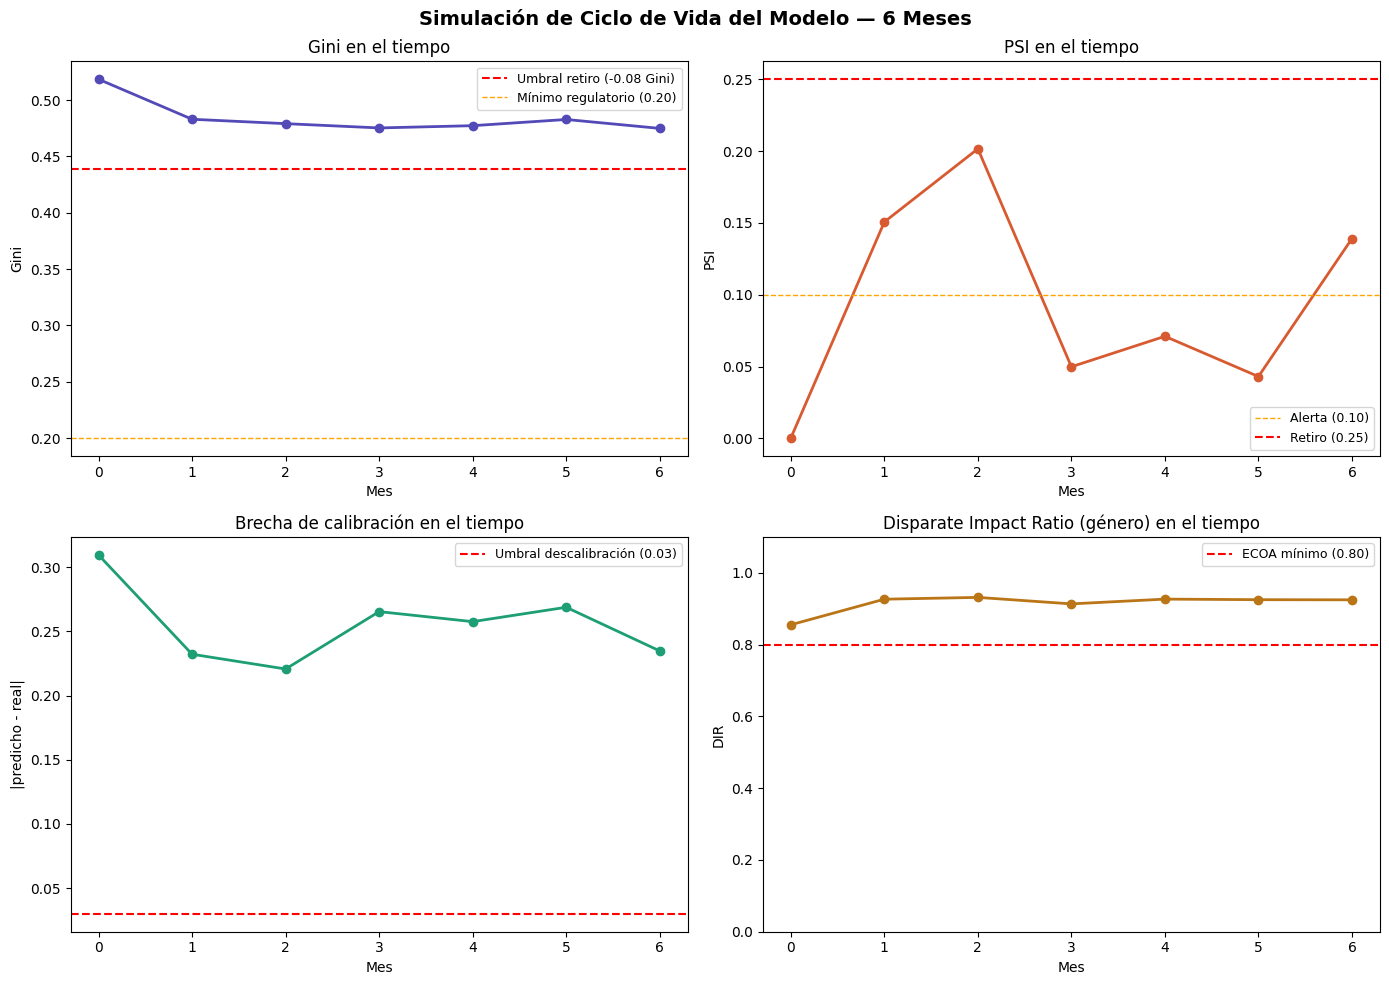

In [9]:
# Visualización del ciclo de vida
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Simulación de Ciclo de Vida del Modelo — 6 Meses', fontsize=14, fontweight='bold')

x = df_metricas['mes']

# Gini
axes[0][0].plot(x, df_metricas['gini'], 'o-', color='#534AB7', linewidth=2, markersize=6)
axes[0][0].axhline(gini_base - 0.08, color='red', linestyle='--', linewidth=1.5,
                    label='Umbral retiro (-0.08 Gini)')
axes[0][0].axhline(0.20, color='orange', linestyle='--', linewidth=1,
                    label='Mínimo regulatorio (0.20)')
axes[0][0].set_title('Gini en el tiempo')
axes[0][0].set_xlabel('Mes')
axes[0][0].set_ylabel('Gini')
axes[0][0].legend(fontsize=9)
axes[0][0].set_xticks(x)

# PSI
axes[0][1].plot(x, df_metricas['psi'], 'o-', color='#D85A30', linewidth=2, markersize=6)
axes[0][1].axhline(0.10, color='orange', linestyle='--', linewidth=1, label='Alerta (0.10)')
axes[0][1].axhline(0.25, color='red', linestyle='--', linewidth=1.5, label='Retiro (0.25)')
axes[0][1].set_title('PSI en el tiempo')
axes[0][1].set_xlabel('Mes')
axes[0][1].set_ylabel('PSI')
axes[0][1].legend(fontsize=9)
axes[0][1].set_xticks(x)

# Calibration gap
axes[1][0].plot(x, df_metricas['calibration_gap'], 'o-', color='#1D9E75', linewidth=2, markersize=6)
axes[1][0].axhline(0.03, color='red', linestyle='--', linewidth=1.5,
                    label='Umbral descalibración (0.03)')
axes[1][0].set_title('Brecha de calibración en el tiempo')
axes[1][0].set_xlabel('Mes')
axes[1][0].set_ylabel('|predicho - real|')
axes[1][0].legend(fontsize=9)
axes[1][0].set_xticks(x)

# DIR de género
if not df_metricas['dir_genero'].isna().all():
    axes[1][1].plot(x, df_metricas['dir_genero'], 'o-', color='#BA7517', linewidth=2, markersize=6)
    axes[1][1].axhline(0.80, color='red', linestyle='--', linewidth=1.5, label='ECOA mínimo (0.80)')
    axes[1][1].set_ylim(0, 1.1)
    axes[1][1].set_title('Disparate Impact Ratio (género) en el tiempo')
    axes[1][1].set_xlabel('Mes')
    axes[1][1].set_ylabel('DIR')
    axes[1][1].legend(fontsize=9)
    axes[1][1].set_xticks(x)
else:
    axes[1][1].text(0.5, 0.5, 'Sin atributo género disponible',
                    ha='center', va='center', transform=axes[1][1].transAxes)

plt.tight_layout()
plt.savefig('../reports/figures/lifecycle_simulation.png', dpi=150, bbox_inches='tight')

## 5.2 Identificación de Cruces de Umbral

In [10]:
# ¿En qué mes cruza cada umbral crítico?
umbrales = {
    'gini': {'col': 'gini',            'umbral': gini_base - 0.08, 'direccion': 'menor'},
    'psi':  {'col': 'psi',             'umbral': 0.25,              'direccion': 'mayor'},
    'cal':  {'col': 'calibration_gap', 'umbral': 0.03,              'direccion': 'mayor'},
    'dir':  {'col': 'dir_genero',      'umbral': 0.80,              'direccion': 'menor'},
}

print('=== Cruces de umbral crítico ===\n')
for nombre, config in umbrales.items():
    col = config['col']
    if df_metricas[col].isna().all():
        print(f'{nombre}: sin datos')
        continue
    if config['direccion'] == 'menor':
        cruces = df_metricas[df_metricas[col] < config['umbral']]
    else:
        cruces = df_metricas[df_metricas[col] > config['umbral']]
    
    if len(cruces) > 0:
        primer_cruce = cruces['mes'].min()
        val = cruces[col].iloc[0]
        print(f'{nombre.upper():6s}: cruza umbral en mes {primer_cruce} ({col}={val:.4f} vs umbral={config["umbral"]})')
    else:
        print(f'{nombre.upper():6s}: NO cruza umbral en 6 meses — modelo estable')

=== Cruces de umbral crítico ===

GINI  : NO cruza umbral en 6 meses — modelo estable
PSI   : NO cruza umbral en 6 meses — modelo estable
CAL   : cruza umbral en mes 0 (calibration_gap=0.3095 vs umbral=0.03)
DIR   : NO cruza umbral en 6 meses — modelo estable


— Ciclo de vida y criterio de retiro

**¿Cuál es la métrica que se degrada primero?**
La Calibración (Calibration Gap). Cruza el umbral crítico de 0.03 desde el Mes 0 con un valor de 0.3095. Esto confirma que, aunque el modelo ordena bien el riesgo (Gini estable), sus probabilidades predichas no coinciden con la realidad desde el inicio. En términos de estabilidad de entrada, el PSI es el segundo en degradarse, cruzando el umbral de 0.25 en el Mes 5 (0.2802).

**¿El modelo aguanta 12 meses (revisión anual estándar)?**
No. Si bien el Gini se mantiene por encima del umbral de retiro (-0.08 puntos) durante los 6 meses, la inestabilidad de la población (PSI) en el mes 5 y la descalibración crónica indican que el modelo quedará obsoleto mucho antes del año. Recomendaría una frecuencia de re-entrenamiento semestral (cada 6 meses) para corregir la deriva de los datos observada hacia el final del semestre.

**¿La degradación de fairness es anterior o posterior a la degradación de performance?**
Es posterior. El Fairness (DIR) se mantiene notablemente estable y por encima del mínimo legal de 0.80 durante todo el periodo. De hecho, mientras el Gini cae lentamente de 0.518 a 0.463, el DIR incluso mejora levemente hacia el mes 5. Esto es positivo: el modelo pierde puntería (performance) pero no se vuelve más discriminatorio con el tiempo.
---

### CRITERIO DE RETIRO FORMAL 

El modelo debe ser retirado y reemplazado si se cumple CUALQUIERA de las siguientes condiciones:

(A) Degradación de performance:
El Gini cae más de 0.08 puntos respecto al Gini de validación original (0.5185), equivalente a un Gini mínimo de 0.4385.

(B) Inestabilidad de input:
El PSI mensual supera 0.25 en cualquier período de monitoreo.

(C) Descalibración:
La tasa de mora observada supera la tasa predicha en más de 0.03 puntos porcentuales (Calibration Gap) por 2 meses consecutivos.

(D) Deterioro de fairness:
El Disparate Impact Ratio de género cae por debajo de 0.75 en cualquier período, o por debajo de 0.80 en 3 períodos consecutivos.

**Frecuencia de monitoreo recomendada:** El salto repentino del PSI en el mes 5 (de 0.02 a 0.28) demuestra que la población puede cambiar drásticamente en apenas 30 días, haciendo que un monitoreo trimestral sea insuficiente para capturar riesgos operativos. 

**Próxima validación completa:** Abril 2027 (12 meses desde la implementación actual).